In [1]:
import pandas as pd

In [2]:
data = {
    'job_skills': ['Python', 'sql', 'java', 'c++', 'c#', 'javascript', 'html', 'css', 'php', 'ruby'],
    'skill_count': [30, 25, 20, 15, 10, 5, 4, 3, 2, 1],
    'skill_pay': [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]
}

df = pd.DataFrame(data)


In [3]:
df

,job_skills,skill_count,skill_pay
0,Python,30,100
1,sql,25,90
2,java,20,80
3,c++,15,70
4,c#,10,60
5,javascript,5,50
6,html,4,40
7,css,3,30
8,php,2,20
9,ruby,1,10


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from datasets import load_dataset
import ast


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Phython\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df_data_Analyst = df[df['job_title_short'] == 'Data Analyst'].copy()

In [6]:
df_skills = df_data_Analyst.explode('job_skills')

In [7]:
df_skills.groupby('job_skills').size()

job_skills
airflow       2002
airtable        88
alteryx       4570
angular        376
angular.js       2
              ... 
wrike           39
wsl             16
xamarin          2
yarn            76
zoom           465
Length: 235, dtype: int64

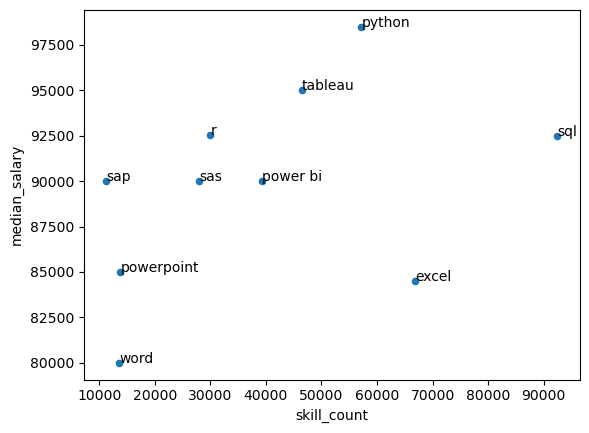

In [8]:
skill_stats = df_skills.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skill_stat = skill_stats.sort_values(by='skill_count', ascending=False).head(10)
skill_stat.plot(kind='scatter', x='skill_count', y='median_salary')



for i, txt in enumerate(skill_stat.index):
    plt.text(skill_stat['skill_count'].iloc[i], skill_stat['median_salary'].iloc[i], txt)

plt.show()

In [9]:
skill_stats = df_skills.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skill_stat = skill_stats.sort_values(by='skill_count', ascending=False).head(10)